In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from scipy.optimize import curve_fit

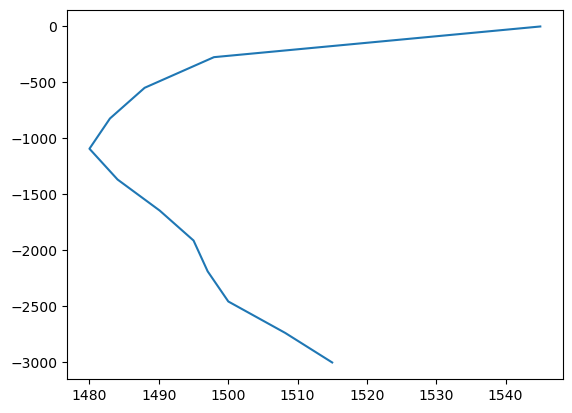

In [2]:
n = 10000
y = np.linspace(0, -3000, n)
v = [1545, 1498, 1488, 1483, 1480, 1484, 1490, 1495, 1497, 1500, 1508, 1515]
x = interp.interp1d(np.arange(len(v)), v)(np.linspace(0, len(v)-1, len(y)))

plt.figure()
plt.plot(x, y)
plt.show()

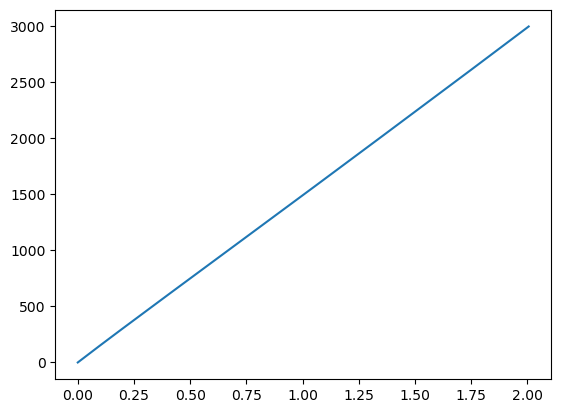

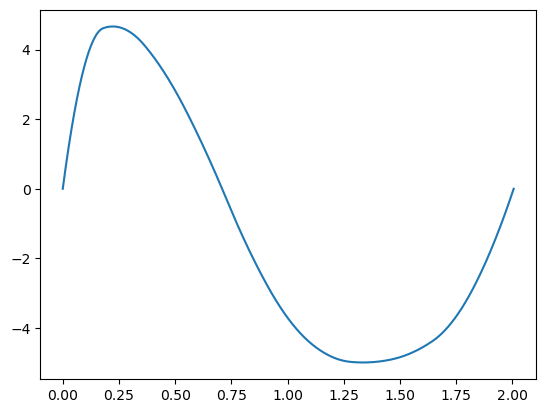

[0, np.float64(0.1545), np.float64(0.3089948294829483), np.float64(0.46348448844884493), np.float64(0.6179741474147415), np.float64(0.7724586358635864), np.float64(0.9269431243124313), np.float64(1.0814224422442245), np.float64(1.2359017601760176), np.float64(1.3903759075907591), np.float64(1.5448500550055007), np.float64(1.6993190319031903), np.float64(1.8537880088008802), np.float64(2.0082518151815183), np.float64(2.1627156215621564), np.float64(2.3171742574257426), np.float64(2.471632893289329), np.float64(2.6260863586358636), np.float64(2.7805398239823984), np.float64(2.9349881188118814), np.float64(3.0894364136413643), np.float64(3.2438795379537955), np.float64(3.3983226622662266), np.float64(3.5527606160616063), np.float64(3.707198569856986), np.float64(3.861631353135314), np.float64(4.016064136413641), np.float64(4.170491749174918), np.float64(4.324919361936194), np.float64(4.479341804180419), np.float64(4.633764246424644), np.float64(4.788181518151816), np.float64(4.94259878987

In [14]:
depth = 0
depths = []
times = []
time = 0
while True:
    speed = 0
    ii = 0
    d = 0
    if depth >= -y[-1]:
        break
    for d in y:
        if -d >= depth:
            speed = x[ii] # x[D]
            break
        ii += 1
    depths.append(depth)
    times.append(time)
    time += (1/n)
    depth += (1/n) * speed


plt.figure()
plt.plot(times, depths)
plt.show()

linearvalues = np.linspace(depths[0], depths[-1], len(depths))

plt.figure()
plt.plot(times, depths-linearvalues)
plt.show()


print(depths)
print(times)


coeffs: [   4.99435417 1480.89954598    6.86092548]
4.994354172564364*x² + 1480.8995459775085*y + 6.860925475293451


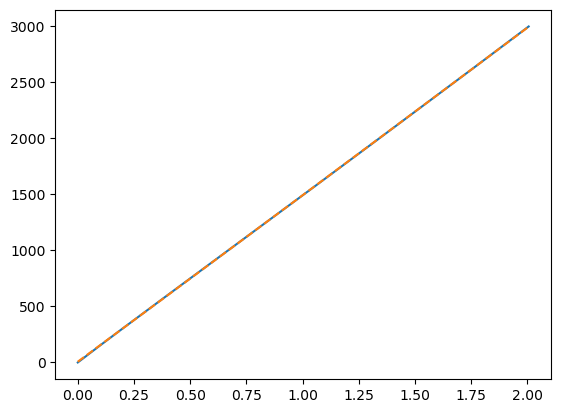

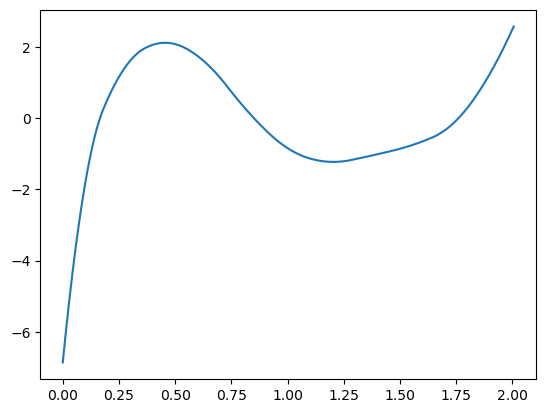

In [26]:
from scipy.optimize import curve_fit

def quad(x, a, b, c):
    return a*x**2 + b*x + c


coeffs = np.polyfit(times, depths, 2)
print(f"coeffs: {coeffs}")
print(f"{coeffs[0]}*x² + {coeffs[1]}*y + {coeffs[2]}")

c = [quad(v, popt[0], popt[1], popt[2]) for v in times]

plt.figure()
plt.plot(times, depths)
plt.plot(times, c, linestyle ="--")
plt.show()

plt.figure()
plt.plot(times, np.array(depths)-np.array(c))
plt.show()